In [2]:
import pandas as pd   #importing Pandas Library
import seaborn as sns  # importing Seaborn library
from sklearn.model_selection import train_test_split    # for spliting the train and test data
from sklearn.preprocessing import StandardScaler        # for scalling variablen into one unit
from sklearn.linear_model import LinearRegression       #Regresssion (for pridiction)
from sklearn.metrics import r2_score

In [3]:
df= pd.read_csv(r'D:\datasets\avocado.csv')  # Data Loading--
df

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,7,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,8,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,9,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,10,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [4]:
# Data Information Gathering----
df.shape

(18249, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns =["Unnamed: 0","Date","4046","4225","4770","XLarge Bags"] , axis = 1 , inplace = True)

In [31]:
df

,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,type,year,region
0,1.33,64236.62,8696.87,8603.62,93.25,0,2015,0
1,1.35,54876.98,9505.56,9408.07,97.49,0,2015,0
2,0.93,118220.22,8145.35,8042.21,103.14,0,2015,0
3,1.08,78992.15,5811.16,5677.40,133.76,0,2015,0
4,1.28,51039.60,6183.95,5986.26,197.69,0,2015,0
...,...,...,...,...,...,...,...,...
18244,1.63,17074.83,13498.67,13066.82,431.85,1,2018,53
18245,1.71,13888.04,9264.84,8940.04,324.80,1,2018,53
18246,1.87,13766.76,9394.11,9351.80,42.31,1,2018,53
18247,1.93,16205.22,10969.54,10919.54,50.00,1,2018,53


In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
df['region'] = le.fit_transform(df['region'])

In [33]:
df

,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,type,year,region
0,1.33,64236.62,8696.87,8603.62,93.25,0,2015,0
1,1.35,54876.98,9505.56,9408.07,97.49,0,2015,0
2,0.93,118220.22,8145.35,8042.21,103.14,0,2015,0
3,1.08,78992.15,5811.16,5677.40,133.76,0,2015,0
4,1.28,51039.60,6183.95,5986.26,197.69,0,2015,0
...,...,...,...,...,...,...,...,...
18244,1.63,17074.83,13498.67,13066.82,431.85,1,2018,53
18245,1.71,13888.04,9264.84,8940.04,324.80,1,2018,53
18246,1.87,13766.76,9394.11,9351.80,42.31,1,2018,53
18247,1.93,16205.22,10969.54,10919.54,50.00,1,2018,53


<Axes: >

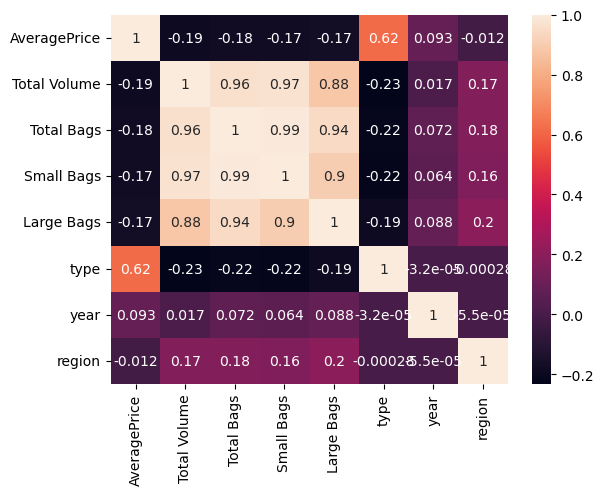

In [34]:
# Heat map---
sns.heatmap(df.corr(numeric_only = True), annot = True)

In [35]:
# Stepp- 5 (Find X and Y)
x = df.drop(['AveragePrice'], axis=1)
y= df['AveragePrice']

In [36]:
#Step 6 (Train_Test Split)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.20, random_state= 42)

In [37]:
#To Apply Regression Algorithm--
regression = LinearRegression()
regression.fit(x_train,y_train)
y_pred = regression.predict(x_test)
score= r2_score(y_test,y_pred)
print(score)

0.38018853947951314
